<a href="https://colab.research.google.com/github/mekaviraj/ML_sem5/blob/main/DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#SETUP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from tensorflow.keras.datasets import fashion_mnist

# WEEK 1


1.Build a Simple Neural Network with PyTorch

In [ ]:
# Importing required libraries
import torch                      # Core PyTorch library
import torch.nn as nn             # Neural network module
import torch.optim as optim       # Optimizers

# -------------------------------
# Step 1: Create Dummy Dataset
# -------------------------------

# Generate 100 samples with 3 input features
x = torch.randn(100, 3)

# Generate 100 target outputs (1 value per sample)
y = torch.randn(100, 1)

# -------------------------------
# Step 2: Define Neural Network
# -------------------------------

class SimpleNet(nn.Module):

    def __init__(self):
        super(SimpleNet, self).__init__()

        # Linear layer: 3 input features → 1 output
        self.linear = nn.Linear(3, 1)

    def forward(self, x):
        # Forward pass
        return self.linear(x)

# Create model instance
model = SimpleNet()

# -------------------------------
# Step 3: Define Loss Function
# -------------------------------

loss_function = nn.MSELoss()   # Mean Squared Error

# -------------------------------
# Step 4: Define Optimizer
# -------------------------------

optimizer = optim.Adam(
    model.parameters(),        # Model parameters to update
    lr=0.01                    # Learning rate
)

# -------------------------------
# Step 5: Training Loop
# -------------------------------

for epoch in range(100):

    # Forward pass
    y_pred = model(x)

    # Calculate loss
    loss = loss_function(y_pred, y)

    # Clear previous gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

# -------------------------------
# Step 6: Print Final Loss
# -------------------------------

print("Final Loss:", loss.item())

Final Loss: 0.781740665435791


2.Simple Neural Network with TensorFlow

In [ ]:
import tensorflow as tf

# Create dummy data
x = tf.random.normal((100, 3))
y = tf.random.normal((100, 1))

# Define model properly (NEW STANDARD)
model = tf.keras.Sequential([
    tf.keras.Input(shape=(3,)),   # Proper input layer
    tf.keras.layers.Dense(1)      # Output layer
])

# Compile model
model.compile(
    optimizer='adam',
    loss='mse'
)

# Train model
model.fit(x, y, epochs=100, verbose=0)

# Evaluate
loss = model.evaluate(x, y, verbose=0)

print("Final Loss:", loss)

Final Loss: 2.317838668823242


# WEEK 2


1.Implement AND and OR using Single Perceptron

In [ ]:
import numpy as np

# Step Activation Function
def step(x):
    return 1 if x >= 0 else 0

# Perceptron Function
def perceptron(x, w, b):
    z = np.dot(x, w) + b
    return step(z)

# Input dataset
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

# ---------------- AND Gate ----------------

print("AND Gate")

w_and = np.array([1,1])
b_and = -1.5

for x in X:
    print(x, "->", perceptron(x, w_and, b_and))

# ---------------- OR Gate ----------------

print("\nOR Gate")

w_or = np.array([1,1])
b_or = -0.5

for x in X:
    print(x, "->", perceptron(x, w_or, b_or))

AND Gate
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1

OR Gate
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1


2.XOR and XNOR Feasibility

In [ ]:
# Attempt XOR with single perceptron

w = np.array([1,1])
b = -0.5

print("Attempt XOR")
for x in X:
    print(x, "->", perceptron(x, w, b))

Attempt XOR
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1


3.XOR Using Multi-Layer Perceptron

In [ ]:
import tensorflow as tf

# XOR Dataset
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,1,1,0])

# Define MLP Model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy')

model.fit(X, y, epochs=500, verbose=0)

print("Predictions:")
print(np.round(model.predict(X)))

Predictions:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
[[0.]
 [1.]
 [1.]
 [0.]]


4.Demonstrate Harsh Threshold

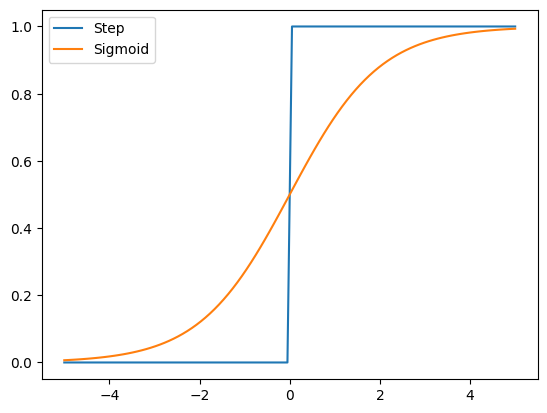

In [ ]:
import matplotlib.pyplot as plt

x = np.linspace(-5,5,100)

step_values = [step(i) for i in x]
sigmoid_values = 1/(1+np.exp(-x))

plt.plot(x, step_values, label="Step")
plt.plot(x, sigmoid_values, label="Sigmoid")
plt.legend()
plt.show()

5.Perceptron Learning Algorithm (Movie Dataset)

In [ ]:
# Movie dataset
X = np.array([
    [1,1,1,0.9],
    [1,0,1,0.8],
    [0,1,0,0.4],
    [0,0,0,0.2]
])

y = np.array([1,1,0,0])

w = np.zeros(4)
b = 0
lr = 0.1

for epoch in range(10):
    for i in range(len(X)):
        y_pred = step(np.dot(X[i], w) + b)
        error = y[i] - y_pred
        w += lr * error * X[i]
        b += lr * error

print("Final Weights:", w)
print("Final Bias:", b)

Final Weights: [ 0.1  -0.1   0.1   0.01]
Final Bias: -0.1


# WEEK 3

1.Implement MLP by Varying Learning Rate and Plot Loss vs Learning Rate

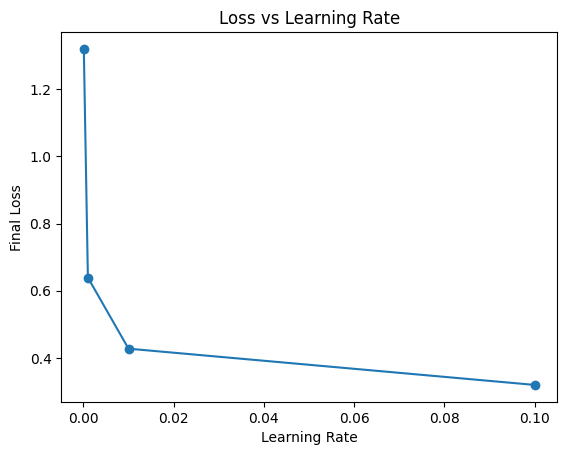

In [ ]:
# Import required libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------
# Step 1: Load Fashion MNIST Dataset
# ----------------------------------

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten images (28x28 → 784)
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# ----------------------------------
# Step 2: Define Learning Rates
# ----------------------------------

learning_rates = [0.1, 0.01, 0.001, 0.0001]
final_losses = []

# ----------------------------------
# Step 3: Train Model for Each LR
# ----------------------------------

for lr in learning_rates:

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(784,)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.SGD(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy'
    )

    history = model.fit(
        X_train, y_train,
        epochs=5,
        verbose=0
    )

    final_loss = history.history['loss'][-1]
    final_losses.append(final_loss)

# ----------------------------------
# Step 4: Plot Graph
# ----------------------------------

plt.plot(learning_rates, final_losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss")
plt.title("Loss vs Learning Rate")
plt.show()

2.Implement MLP using Gradient Descent

In [ ]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(784,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6814 - loss: 1.0136 - val_accuracy: 0.8088 - val_loss: 0.5617
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8220 - loss: 0.5260 - val_accuracy: 0.8284 - val_loss: 0.5020
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8355 - loss: 0.4794 - val_accuracy: 0.8341 - val_loss: 0.4800
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8442 - loss: 0.4498 - val_accuracy: 0.8405 - val_loss: 0.4602
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8519 - loss: 0.4311 - val_accuracy: 0.8428 - val_loss: 0.4460
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8571 - loss: 0.4155 - val_accuracy: 0.8412 - val_loss: 0.4486
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8601 - loss: 0.4032 - val_accuracy: 0.8451 - val_loss: 0.4370
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8626 - loss: 0.3931 - 

3.Perceptron on IRIS Dataset

In [ ]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Try different learning rates
for lr in [1.0, 0.1, 0.01]:

    model = Perceptron(
        eta0=lr,
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("Learning Rate:", lr)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print()

Learning Rate: 1.0
Accuracy: 0.6333333333333333

Learning Rate: 0.1
Accuracy: 0.6333333333333333

Learning Rate: 0.01
Accuracy: 0.6



4.MLP on Dataset (Parameter Exploration)

In [ ]:
import tensorflow as tf
import numpy as np

# Load Fashion MNIST Dataset (re-loading to ensure correct data is used)
(X_train, y_train), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize data
X_train = X_train / 255.0

# Flatten images (28x28 → 784)
X_train = X_train.reshape(-1, 784)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(784,)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7917 - loss: 0.5954
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8639 - loss: 0.3693
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8800 - loss: 0.3262
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8848 - loss: 0.3063
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8958 - loss: 0.2793
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8998 - loss: 0.2684
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9068 - loss: 0.2462
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9081 - loss: 0.2407
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9113 - loss: 0.2333
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9156 - loss: 0.2230


5.MLP for MNIST Handwritten Digits

In [ ]:
# Load MNIST
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(784,)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=10)

loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8916 - loss: 0.3574
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9738 - loss: 0.0865
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9818 - loss: 0.0560
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9866 - loss: 0.0409
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9910 - loss: 0.0280
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9910 - loss: 0.0269
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9929 - loss: 0.0220
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9940 - loss: 0.0189
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9954 - loss: 0.0133
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9955 - loss: 0.0144
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9743 - loss: 0.1211
Test Accuracy: 0.9793000221252441


# WEEK 4

Implement MLP Using Different Types of Gradient Descent for XOR

In [ ]:
#PART 1....XOR DATASET
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# XOR dataset
X = np.array(
    [
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1]
    ]
)

y = np.array([0, 1, 1, 0])

# Function to train model with given optimizer
def train_optimizer(optimizer, name):

    model = tf.keras.Sequential(
        [
            tf.keras.Input(shape=(2,)),
            tf.keras.layers.Dense(8, activation='relu'),
            tf.keras.layers.Dense(1, activation='sigmoid'),
        ]
    )

    model.compile(optimizer=optimizer, loss='binary_crossentropy')

    history = model.fit(X, y, epochs=300, verbose=0)

    final_loss = history.history['loss'][-1]
    print(name, "Final Loss:", final_loss)

    return final_loss

#...............Now Train with All Optimizers...............
losses = {}

# Batch GD (SGD with full batch)
losses["BGD"] = train_optimizer(
    tf.keras.optimizers.SGD(learning_rate=0.1), "Batch GD"
)

# SGD (batch size 1)
losses["SGD"] = train_optimizer(
    tf.keras.optimizers.SGD(learning_rate=0.1), "SGD"
)

# Momentum
losses["Momentum"] = train_optimizer(
    tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9), "Momentum"
)

# Nesterov
losses["Nesterov"] = train_optimizer(
    tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9, nesterov=True),
    "Nesterov",
)

# Adagrad
losses["Adagrad"] = train_optimizer(
    tf.keras.optimizers.Adagrad(learning_rate=0.1), "Adagrad"
)

# RMSProp
losses["RMSProp"] = train_optimizer(
    tf.keras.optimizers.RMSprop(learning_rate=0.01), "RMSProp"
)

# Adadelta
losses["Adadelta"] = train_optimizer(
    tf.keras.optimizers.Adadelta(), "Adadelta"
)

# Adam
losses["Adam"] = train_optimizer(
    tf.keras.optimizers.Adam(learning_rate=0.01), "Adam"
)
#..............PART 2....Test on Real Dataset (Fashion MNIST)
# Load dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

X_train = X_train / 255.0
X_train = X_train.reshape(-1, 784)

def train_fashion(optimizer, name):

    model = tf.keras.Sequential(
        [
            tf.keras.Input(shape=(784,)),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dense(10, activation='softmax'),
        ]
    )

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    history = model.fit(X_train, y_train, epochs=5, verbose=0)

    acc = history.history['accuracy'][-1]
    print(name, "Accuracy:", acc)

    return acc


#................Train with Major Optimizers.........
train_fashion(tf.keras.optimizers.SGD(0.01), "SGD")
train_fashion(tf.keras.optimizers.SGD(0.01, momentum=0.9), "Momentum")
train_fashion(tf.keras.optimizers.RMSprop(0.001), "RMSProp")
train_fashion(tf.keras.optimizers.Adam(0.001), "Adam")

Batch GD Final Loss: 0.15763604640960693
SGD Final Loss: 0.18381839990615845
Momentum Final Loss: 0.006015644874423742
Nesterov Final Loss: 0.007357585709542036
Adagrad Final Loss: 0.08654376119375229
RMSProp Final Loss: 0.013676752336323261
Adadelta Final Loss: 0.6983456015586853
Adam Final Loss: 0.02074703946709633
SGD Accuracy: 0.8538166880607605
Momentum Accuracy: 0.8820833563804626
RMSProp Accuracy: 0.8905166387557983
Adam Accuracy: 0.8922833204269409


0.8922833204269409

# WEEK 5

Implement MLP using Different Regularization Techniques

In [ ]:
#.............Base Model (Without Regularization)
import tensorflow as tf
import numpy as np

# Load dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# Base Model
def base_model():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(784,)),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = base_model()
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7869 - loss: 0.6066 - val_accuracy: 0.8559 - val_loss: 0.3927
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8636 - loss: 0.3725 - val_accuracy: 0.8657 - val_loss: 0.3662
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8775 - loss: 0.3324 - val_accuracy: 0.8697 - val_loss: 0.3638
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8879 - loss: 0.3045 - val_accuracy: 0.8744 - val_loss: 0.3473
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8914 - loss: 0.2862 - val_accuracy: 0.8768 - val_loss: 0.3475
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8986 - loss: 0.2655 - val_accuracy: 0.8775 - val_loss: 0.3319
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9045 - loss: 0.2512 - val_accuracy: 0.8851 - val_loss: 0.3370
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9076 - loss: 0.2416 - 

1. L2 Regularization

In [ ]:
from tensorflow.keras import regularizers

def l2_model():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(784,)),
        tf.keras.layers.Dense(256, activation='relu',
                              kernel_regularizer=regularizers.l2(0.001)),
        tf.keras.layers.Dense(128, activation='relu',
                              kernel_regularizer=regularizers.l2(0.001)),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = l2_model()
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7806 - loss: 0.9367 - val_accuracy: 0.8333 - val_loss: 0.5963
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8502 - loss: 0.5470 - val_accuracy: 0.8358 - val_loss: 0.5554
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8597 - loss: 0.4938 - val_accuracy: 0.8596 - val_loss: 0.4833
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8652 - loss: 0.4580 - val_accuracy: 0.8615 - val_loss: 0.4701
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8696 - loss: 0.4388 - val_accuracy: 0.8589 - val_loss: 0.4754
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8743 - loss: 0.4261 - val_accuracy: 0.8595 - val_loss: 0.4628
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8727 - loss: 0.4201 - val_accuracy: 0.8548 - val_loss: 0.4815
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8774 - loss: 0.4111 - 

2.Dropout

In [ ]:
def dropout_model():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(784,)),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = dropout_model()
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6717 - loss: 0.9112 - val_accuracy: 0.8318 - val_loss: 0.4676
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8104 - loss: 0.5232 - val_accuracy: 0.8405 - val_loss: 0.4257
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8259 - loss: 0.4828 - val_accuracy: 0.8477 - val_loss: 0.4128
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8373 - loss: 0.4457 - val_accuracy: 0.8515 - val_loss: 0.3978
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8438 - loss: 0.4315 - val_accuracy: 0.8553 - val_loss: 0.3967
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8460 - loss: 0.4181 - val_accuracy: 0.8598 - val_loss: 0.3842
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8507 - loss: 0.4172 - val_accuracy: 0.8615 - val_loss: 0.3792
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8516 - loss: 0.4065 - 

3.Early Stopping

In [ ]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model = base_model()

model.fit(X_train, y_train,
          epochs=50,
          validation_data=(X_test, y_test),
          callbacks=[callback])

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7857 - loss: 0.5984 - val_accuracy: 0.8451 - val_loss: 0.4200
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8681 - loss: 0.3593 - val_accuracy: 0.8608 - val_loss: 0.3849
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8815 - loss: 0.3220 - val_accuracy: 0.8691 - val_loss: 0.3703
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8875 - loss: 0.3035 - val_accuracy: 0.8799 - val_loss: 0.3364
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8929 - loss: 0.2858 - val_accuracy: 0.8692 - val_loss: 0.3520
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9010 - loss: 0.2635 - val_accuracy: 0.8752 - val_loss: 0.3418
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9058 - loss: 0.2515 - val_accuracy: 0.8808 - val_loss: 0.3390


4.Adding Noise to Inputs

In [ ]:
noise_factor = 0.2
X_train_noisy = X_train + noise_factor * np.random.normal(size=X_train.shape)

model = base_model()
model.fit(X_train_noisy, y_train,
          epochs=10,
          validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7675 - loss: 0.6436 - val_accuracy: 0.8527 - val_loss: 0.4086
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8575 - loss: 0.3818 - val_accuracy: 0.8567 - val_loss: 0.3903
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8787 - loss: 0.3270 - val_accuracy: 0.8470 - val_loss: 0.4181
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8937 - loss: 0.2878 - val_accuracy: 0.8668 - val_loss: 0.3675
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9034 - loss: 0.2542 - val_accuracy: 0.8783 - val_loss: 0.3611
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9146 - loss: 0.2241 - val_accuracy: 0.8633 - val_loss: 0.4372
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9254 - loss: 0.2011 - val_accuracy: 0.8732 - val_loss: 0.3832
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9320 - loss: 0.1805 - 

5.Dataset Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import numpy as np

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

X_train_images = X_train.reshape(-1,28,28,1)

datagen.fit(X_train_images)

# Define a new model compatible with 4D image input (28, 28, 1)
def augmented_model():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28, 1)), # Accept 4D image input
        tf.keras.layers.Flatten(),         # Flatten the images to 784 features
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = augmented_model() # Use the new model

# Reshape X_test for validation data as well
X_test_images = X_test.reshape(-1,28,28,1)

model.fit(datagen.flow(X_train_images, y_train, batch_size=64),
          epochs=10,
          validation_data=(X_test_images, y_test))

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - accuracy: 0.6555 - loss: 0.9179 - val_accuracy: 0.7895 - val_loss: 0.5619
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.7658 - loss: 0.6218 - val_accuracy: 0.8082 - val_loss: 0.5142
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.7831 - loss: 0.5690 - val_accuracy: 0.8206 - val_loss: 0.4760
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.7956 - loss: 0.5409 - val_accuracy: 0.8209 - val_loss: 0.4700
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.8034 - loss: 0.5151 - val_accuracy: 0.8157 - val_loss: 0.4683
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.8059 - loss: 0.5027 - val_accuracy: 0.8360 - val_loss: 0.4336
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.8146 - loss: 0.4864 - val_accuracy: 0.8278 - val_loss: 0.4498
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.8142 - loss: 0.4818 - val_accurac

6.Ensemble Methods

In [ ]:
models = []

for i in range(3):
    m = base_model()
    m.fit(X_train, y_train, epochs=5, verbose=0)
    models.append(m)

# Average predictions
preds = [m.predict(X_test) for m in models]
avg_pred = np.mean(preds, axis=0)

final_accuracy = np.mean(np.argmax(avg_pred, axis=1) == y_test)

print("Ensemble Accuracy:", final_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Ensemble Accuracy: 0.8884


7.Parameter Sharing and Tying

# WEEK 6

Implement CNN on MNIST Dataset


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models

# -----------------------------
# Step 1: Load MNIST dataset
# -----------------------------

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape to include channel dimension
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# -----------------------------
# Step 2: Define CNN Model
# -----------------------------

model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dense(10,activation='softmax')
])

# -----------------------------
# Step 3: Compile Model
# -----------------------------

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Step 4: Train Model
# -----------------------------

model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test,y_test)
)

# -----------------------------
# Step 5: Evaluate Model
# -----------------------------

loss,accuracy = model.evaluate(X_test,y_test)

print("Test Accuracy:",accuracy)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9611 - loss: 0.1280 - val_accuracy: 0.9877 - val_loss: 0.0392
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9867 - loss: 0.0423 - val_accuracy: 0.9876 - val_loss: 0.0361
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9910 - loss: 0.0293 - val_accuracy: 0.9876 - val_loss: 0.0338
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9932 - loss: 0.0208 - val_accuracy: 0.9885 - val_loss: 0.0367
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9947 - loss: 0.0161 - val_accuracy: 0.9885 - val_loss: 0.0387
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9885 - loss: 0.0387
Test Accuracy: 0.9884999990463257


Apply CNN on Own Dataset

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models

# -----------------------------
# Load dataset
# -----------------------------

(X_train,y_train),(X_test,y_test) = tf.keras.datasets.fashion_mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# -----------------------------
# CNN Model
# -----------------------------

model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10,activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Train Model
# -----------------------------

model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test,y_test)
)

loss,acc = model.evaluate(X_test,y_test)

print("Accuracy:",acc)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.7989 - loss: 0.5567 - val_accuracy: 0.8642 - val_loss: 0.3683
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8731 - loss: 0.3541 - val_accuracy: 0.8844 - val_loss: 0.3112
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8908 - loss: 0.3037 - val_accuracy: 0.8972 - val_loss: 0.2775
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9024 - loss: 0.2684 - val_accuracy: 0.9014 - val_loss: 0.2664
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9106 - loss: 0.2471 - val_accuracy: 0.9031 - val_loss: 0.2660
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9182 - loss: 0.2244 - val_accuracy: 0.9076 - val_loss: 0.2577
Epoch 7/10
1875/1875 ━━━━━━━━━━

# WEEK 7

Implement AlexNet

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# AlexNet simplified
model = models.Sequential([

    tf.keras.Input(shape=(224,224,3)),

    layers.Conv2D(96,(11,11),strides=4,activation='relu'),
    layers.MaxPooling2D((3,3),strides=2),

    layers.Conv2D(256,(5,5),activation='relu',padding='same'),
    layers.MaxPooling2D((3,3),strides=2),

    layers.Conv2D(384,(3,3),activation='relu',padding='same'),
    layers.Conv2D(384,(3,3),activation='relu',padding='same'),
    layers.Conv2D(256,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((3,3),strides=2),

    layers.Flatten(),

    layers.Dense(4096,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(4096,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10,activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,787,978 (178.48 MB)

 Trainable params: 46,787,978 (178.48 MB)

 Non-trainable params: 0 (0.00 B)

Implement ZFNet

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([

    tf.keras.Input(shape=(224,224,3)),

    layers.Conv2D(96,(7,7),strides=2,activation='relu'),
    layers.MaxPooling2D((3,3),strides=2),

    layers.Conv2D(256,(5,5),activation='relu',padding='same'),
    layers.MaxPooling2D((3,3),strides=2),

    layers.Conv2D(384,(3,3),activation='relu',padding='same'),
    layers.Conv2D(384,(3,3),activation='relu',padding='same'),
    layers.Conv2D(256,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((3,3),strides=2),

    layers.Flatten(),

    layers.Dense(4096,activation='relu'),
    layers.Dense(4096,activation='relu'),

    layers.Dense(10,activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 109, 109, 96)   │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 54, 54, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 54, 54, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   150,999,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,547,786 (654.40 MB)

 Trainable params: 171,547,786 (654.40 MB)

 Non-trainable params: 0 (0.00 B)

Implement VGG16

In [ ]:
model = models.Sequential([

    tf.keras.Input(shape=(224,224,3)),

    # Block 1
    layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(128,(3,3),activation='relu',padding='same'),
    layers.Conv2D(128,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(256,(3,3),activation='relu',padding='same'),
    layers.Conv2D(256,(3,3),activation='relu',padding='same'),
    layers.Conv2D(256,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    # Block 4
    layers.Conv2D(512,(3,3),activation='relu',padding='same'),
    layers.Conv2D(512,(3,3),activation='relu',padding='same'),
    layers.Conv2D(512,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    # Block 5
    layers.Conv2D(512,(3,3),activation='relu',padding='same'),
    layers.Conv2D(512,(3,3),activation='relu',padding='same'),
    layers.Conv2D(512,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(4096,activation='relu'),
    layers.Dense(4096,activation='relu'),

    layers.Dense(10,activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,301,514 (512.32 MB)

 Trainable params: 134,301,514 (512.32 MB)

 Non-trainable params: 0 (0.00 B)

# WEEK 8


To implement GoogleNet (Inception model) using PyTorch.

In [ ]:
import torch
import torchvision.models as models

# Load pretrained GoogleNet
model = models.googlenet(pretrained=True)

# Set to evaluation mode
model.eval()

print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 193MB/s]


GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

To implement ResNet and understand skip connections.

In [ ]:
import torch
import torchvision.models as models

# Load ResNet18
model = models.resnet18(pretrained=True)

model.eval()

print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 172MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# WEEK 9

To visualize convolution and pooling outputs.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 910ms/step


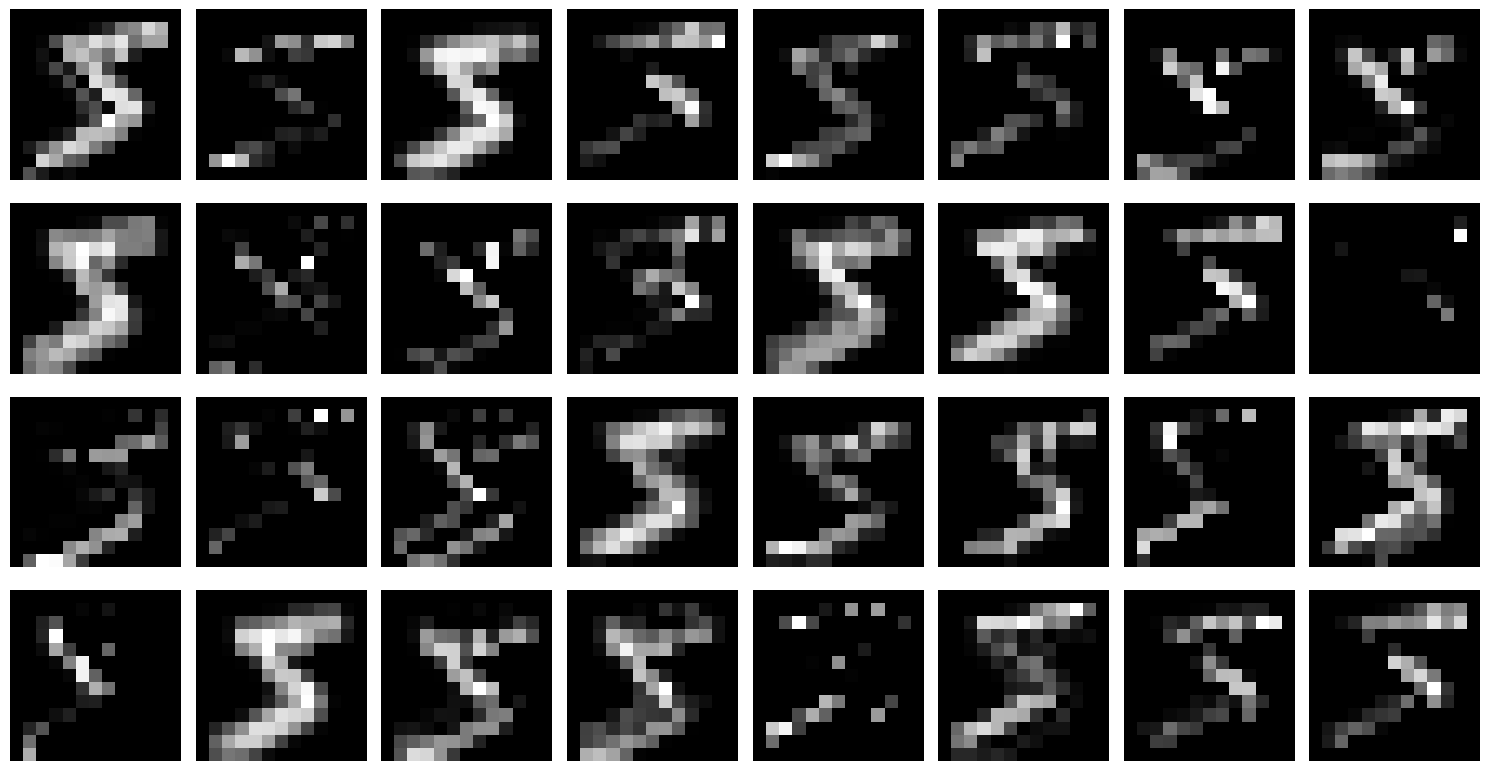

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# -----------------------------
# Load dataset
# -----------------------------
(X_train, y_train), _ = tf.keras.datasets.mnist.load_data()

X_train = X_train / 255.0
X_train = X_train.reshape(-1,28,28,1)

# -----------------------------
# Define CNN model (Functional API)
# -----------------------------
inputs = tf.keras.Input(shape=(28,28,1))

x = tf.keras.layers.Conv2D(32,(3,3),activation='relu')(inputs)
x = tf.keras.layers.MaxPooling2D((2,2))(x)

model = tf.keras.Model(inputs=inputs, outputs=x)

# -----------------------------
# Select image
# -----------------------------
img = X_train[0].reshape(1,28,28,1)

# -----------------------------
# Get feature maps
# -----------------------------
feature_maps = model.predict(img)

# -----------------------------
# Plot in GRID (HORIZONTAL)
# -----------------------------
num_filters = feature_maps.shape[-1]   # total feature maps

cols = 8   # number of columns (horizontal spread)
rows = num_filters // cols

plt.figure(figsize=(15,8))

for i in range(num_filters):
    plt.subplot(rows, cols, i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

# WEEK 10

To visualize important pixels influencing prediction.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.1794


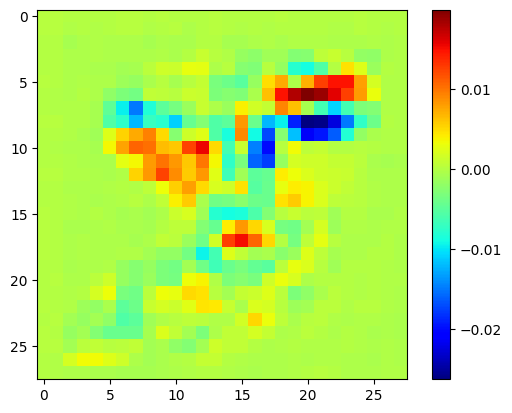

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST
(X_train, y_train), _ = tf.keras.datasets.mnist.load_data()

X_train = X_train / 255.0
X_train = X_train.reshape(-1,28,28,1)

# Simple CNN
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy')

model.fit(X_train,y_train,epochs=1)

# Gradient visualization
img = tf.convert_to_tensor(X_train[0].reshape(1,28,28,1))

with tf.GradientTape() as tape:
    tape.watch(img)
    preds = model(img)
    loss = preds[:,np.argmax(preds[0])]

grads = tape.gradient(loss,img)

plt.imshow(grads[0,:,:,0], cmap='jet')
plt.colorbar()
plt.show()

# WEEK 11

Autoencoders

In [ ]:
import tensorflow as tf

(X_train, _), (X_test, _) = tf.keras.datasets.mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1,784)
X_test = X_test.reshape(-1,784)

# Autoencoder
input_img = tf.keras.Input(shape=(784,))
encoded = tf.keras.layers.Dense(64, activation='relu')(input_img)
decoded = tf.keras.layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = tf.keras.Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(X_train, X_train, epochs=5)



Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.1361
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0833
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0770
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0755
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0748


Denoising AE

In [ ]:
noise = 0.3
X_train_noisy = X_train + noise * tf.random.normal(shape=X_train.shape)

autoencoder.fit(X_train_noisy, X_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0964
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0930
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0926
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0924
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0923


Sparse AE

In [ ]:
activity_regularizer=tf.keras.regularizers.l1(1e-5)

# WEEK 12

RNN + LSTM + GRU + Attention

In [ ]:
import tensorflow as tf
import numpy as np

# =============================
# PART 1: DATA PREPARATION
# =============================
text = "hello world"

chars = sorted(list(set(text)))
char_to_idx = {c:i for i,c in enumerate(chars)}
idx_to_char = {i:c for c,i in char_to_idx.items()}

X = []
y = []

for i in range(len(text)-1):
    X.append([char_to_idx[text[i]]])   # sequence input
    y.append(char_to_idx[text[i+1]])

X = np.array(X)
y = np.array(y)

vocab_size = len(chars)

# =============================
# PART 2: RNN MODEL
# =============================
rnn_model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Embedding(vocab_size, 8),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(vocab_size, activation='softmax')
])

rnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy')

print("\nTraining RNN...")
rnn_model.fit(X, y, epochs=50, verbose=0)

# =============================
# PART 3: LSTM MODEL
# =============================
lstm_model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Embedding(vocab_size, 8),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(vocab_size, activation='softmax')
])

lstm_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy')

print("\nTraining LSTM...")
lstm_model.fit(X, y, epochs=50, verbose=0)

# =============================
# PART 4: GRU MODEL
# =============================
gru_model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Embedding(vocab_size, 8),
    tf.keras.layers.GRU(32),
    tf.keras.layers.Dense(vocab_size, activation='softmax')
])

gru_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy')

print("\nTraining GRU...")
gru_model.fit(X, y, epochs=50, verbose=0)

# =============================
# PART 5: PREDICTION FUNCTION
# =============================
def predict_next(model, char):
    x = np.array([[char_to_idx[char]]])
    pred = model.predict(x, verbose=0)
    return idx_to_char[np.argmax(pred)]

print("\nPredictions:")
print("RNN:", predict_next(rnn_model, 'h'))
print("LSTM:", predict_next(lstm_model, 'h'))
print("GRU:", predict_next(gru_model, 'h'))

# =============================
# PART 6: ENCODER-DECODER
# =============================
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.models import Model

encoder_input = Input(shape=(None, 1))
encoder = LSTM(32, return_state=True)
encoder_output, state_h, state_c = encoder(encoder_input)

encoder_states = [state_h, state_c]

decoder_input = Input(shape=(None, 1))
decoder_lstm = LSTM(32, return_sequences=True, return_state=True)

decoder_output, _, _ = decoder_lstm(decoder_input, initial_state=encoder_states)

decoder_dense = Dense(1)
decoder_output = decoder_dense(decoder_output)

seq2seq_model = Model([encoder_input, decoder_input], decoder_output)

seq2seq_model.compile(optimizer='adam', loss='mse')

print("\nEncoder-Decoder Model Built Successfully")

# =============================
# PART 7: ATTENTION MECHANISM
# =============================
from tensorflow.keras.layers import Attention

query = tf.random.normal((1, 10, 32))
value = tf.random.normal((1, 10, 32))

attention_layer = Attention()
attention_output = attention_layer([query, value])

print("\nAttention Output Shape:", attention_output.shape)


Training RNN...

Training LSTM...

Training GRU...

Predictions:
RNN: l
LSTM: l


GRU: l

Encoder-Decoder Model Built Successfully

Attention Output Shape: (1, 10, 32)


# WEEK 13

Transformer Model (Simplified for Fashion MNIST)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# Load dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten image into sequence (28x28 → 784 tokens)
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# Expand dims for transformer input
X_train = tf.expand_dims(X_train, -1)
X_test = tf.expand_dims(X_test, -1)

# Transformer block
def transformer_block(x):
    attention = layers.MultiHeadAttention(num_heads=2, key_dim=32)(x, x)
    x = layers.Add()([x, attention])
    x = layers.LayerNormalization()(x)

    ffn = layers.Dense(64, activation='relu')(x)
    ffn = layers.Dense(1)(ffn)

    x = layers.Add()([x, ffn])
    return layers.LayerNormalization()(x)

# Model
inputs = tf.keras.Input(shape=(784,1))
x = transformer_block(inputs)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - accuracy: 0.0996 - loss: 2.3028
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.0989 - loss: 2.3028
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.0981 - loss: 2.3028
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.0990 - loss: 2.3028
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.0990 - loss: 2.3028


BERT-style Model (Simplified)

In [ ]:
inputs = tf.keras.Input(shape=(784,1))

x = layers.MultiHeadAttention(num_heads=2, key_dim=32)(inputs, inputs)
x = layers.LayerNormalization()(x)

x = layers.Dense(64, activation='relu')(x)
x = layers.GlobalAveragePooling1D()(x)

outputs = layers.Dense(10, activation='softmax')(x)

bert_model = tf.keras.Model(inputs, outputs)

bert_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

bert_model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.0977 - loss: 2.3028
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.0991 - loss: 2.3028
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.0998 - loss: 2.3027
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.1001 - loss: 2.3028
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.0993 - loss: 2.3028


Vision Transformer (ViT)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# Patch creation
def create_patches(images, patch_size=4):
    patches = tf.image.extract_patches(
        images=images,
        sizes=[1, patch_size, patch_size, 1],
        strides=[1, patch_size, patch_size, 1],
        rates=[1,1,1,1],
        padding='VALID'
    )
    patches = tf.reshape(patches, (tf.shape(images)[0], -1, patches.shape[-1]))
    return patches

# Load data
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train[..., tf.newaxis]
X_test = X_test[..., tf.newaxis]

# Create patches
X_train_patches = create_patches(X_train)
X_test_patches = create_patches(X_test)

# ViT model
inputs = tf.keras.Input(shape=X_train_patches.shape[1:])

x = layers.Dense(64)(inputs)

x = layers.MultiHeadAttention(num_heads=2, key_dim=32)(x, x)
x = layers.LayerNormalization()(x)

x = layers.GlobalAveragePooling1D()(x)

outputs = layers.Dense(10, activation='softmax')(x)

vit_model = tf.keras.Model(inputs, outputs)

vit_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

vit_model.fit(X_train_patches, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5582 - loss: 1.2198
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6344 - loss: 1.0328
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6494 - loss: 0.9931
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6594 - loss: 0.9640
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6664 - loss: 0.9449
